In [1]:
import os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
import seaborn as sns
from scipy.stats import kruskal, ranksums, pearsonr, spearmanr, false_discovery_control
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Patch, FancyArrowPatch


plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07",
 "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
 "PETDWS2B": "2024-08-01",  "PETDWS2C": "2024-08-01",   "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07","MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07", "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}


MT=[]
for f in glob.glob("*EsViritu.detected_virus.info.tsv"):
    df=pd.read_csv(f, sep="\t")
    MT.append(df)

MT=pd.concat(MT)

print(len(MT["family"].unique()))
print(len(MT["genus"].unique()))
print(len(MT["species"].unique()))



MT["Cov_perc"] = MT["covered_bases"] / MT["Asm_length"] * 100
MT = MT.drop(columns=['kingdom', 'phylum', 'tclass', 'order','Segment', 'Assembly'], errors='ignore')
MT=MT[MT["covered_bases"]>=1000]
MT["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in MT["sample_ID"]]
MT["dates"]=MT["sample_ID"].str.replace("_", "").map(dates)

26
62
136


In [2]:
print(len(MT["family"].unique()))
print(len(MT["genus"].unique()))
print(len(MT["species"].unique()))

11
18
38


In [3]:
MT["family"]=MT["family"].str.replace("f__", "")

In [4]:
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
rr=dict(zip(tdf["sample"], tdf["num_seqs"]))
MT["total_reads"]=MT["sample_ID"].map(rr)
# pp["RPM"]=(pp["taxReads"]/pp["total_reads"])*1000000

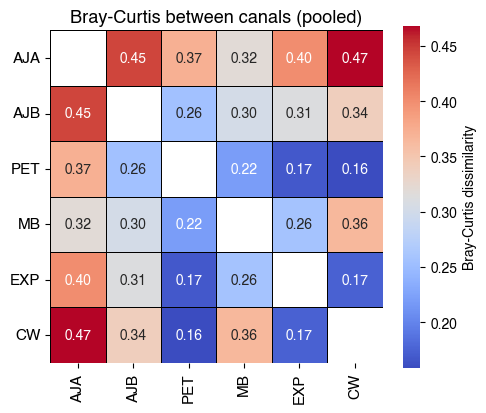

In [5]:
df = MT.copy()
df["read_count"] = pd.to_numeric(df["read_count"], errors="coerce").fillna(0)
df["family"] = df["family"].astype(str).str.replace("f__", "", regex=False)
co = ["AJA", "AJB", "PET", "MB", "EXP", "CW"]  
canal_rel = df.groupby(["canal", "family"], as_index=False)["read_count"].sum().pivot(index="canal", columns="family", values="read_count").fillna(0)
canal_rel = canal_rel.div(canal_rel.sum(1), axis=0)        
canal_rel = canal_rel.loc[[c for c in co if c in canal_rel.index]]

bcp = pd.DataFrame(squareform(pdist(canal_rel.values, metric="braycurtis")),index=canal_rel.index, columns=canal_rel.index)
off = bcp.values[~np.eye(len(bcp), dtype=bool)]
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(bcp, ax=ax, cmap="coolwarm", vmin=off.min(), vmax=off.max(), square=True, linewidths=0.5, linecolor="black", annot=True, fmt=".2f", cbar_kws={"label": "Bray-Curtis dissimilarity"}, mask=np.eye(len(bcp), dtype=bool))

ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=90, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=11)
ax.set_title("Bray-Curtis between canals (pooled)", fontsize=13)
plt.tight_layout()

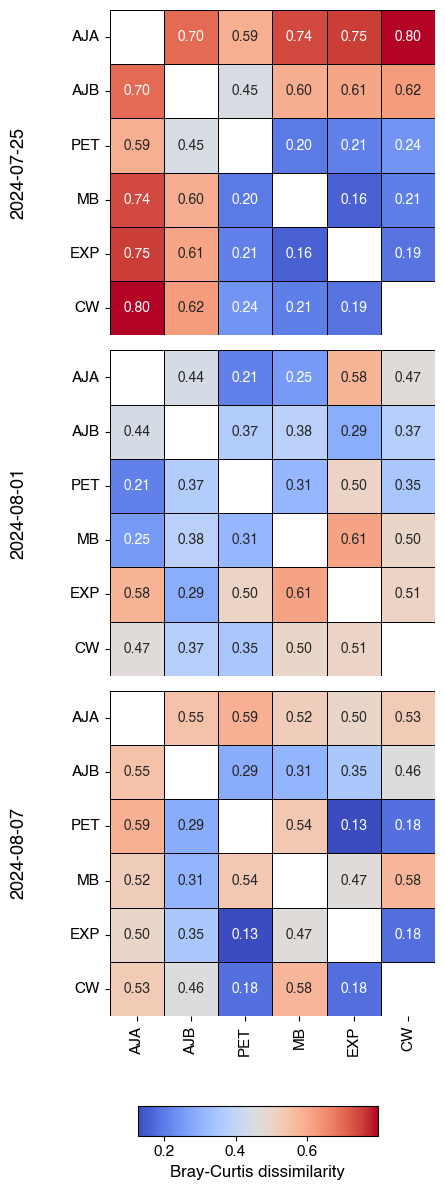

In [6]:
cdf = df.groupby(["dates", "canal", "family"], as_index=False)["read_count"].sum()
def rel_by_date(date):
    comm = cdf[cdf["dates"] == date].pivot(index="canal", columns="family", values="read_count").fillna(0)
    comm = comm.div(comm.sum(1), axis=0)                   
    return comm.loc[[c for c in canal_order if c in comm.index]]

dates = sorted(df["dates"].unique())
rels  = {t: rel_by_date(t) for t in dates}
mats  = {t: pd.DataFrame(squareform(pdist(r.values, metric="braycurtis")), index=r.index, columns=r.index) for t, r in rels.items()}
off_all = np.concatenate([m.values[~np.eye(len(m), dtype=bool)] for m in mats.values()])
vmin, vmax = off_all.min(), off_all.max()
canal_full = [c for c in canal_order if any(c in m.index for m in mats.values())]
fig, axes = plt.subplots(nrows=len(dates), ncols=1, figsize=(4.8, 3.9 * len(dates)), squeeze=False)

for i, date in enumerate(dates):
    ax = axes[i, 0]
    heat = mats[date].reindex(index=canal_full, columns=canal_full)
    sns.heatmap(heat, ax=ax, cmap="coolwarm", vmin=vmin, vmax=vmax, square=True, linewidths=0.5, linecolor="black", annot=True, fmt=".2f", cbar=False, mask=np.eye(len(heat), dtype=bool))
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]) if i < len(dates) - 1 else ax.tick_params(axis="x", rotation=90, labelsize=11)
    ax.tick_params(axis="y", rotation=0, labelsize=11)
    ax.text(-0.28, 0.5, date, transform=ax.transAxes, rotation=90, va="center", ha="center", fontsize=13)

plt.tight_layout(rect=[0, 0.08, 1, 1])
cbar_ax = fig.add_axes([0.25, 0.025, 0.5, 0.025])
sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin, vmax), cmap="coolwarm")
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Bray-Curtis dissimilarity", fontsize=12)
cbar.ax.tick_params(labelsize=11)

In [7]:
rows = []
for date, m in mats.items():
    canals = list(m.index)
    for i, c1 in enumerate(canals):
        for c2 in canals[i + 1:]:               
            bc = m.loc[c1, c2]
            rows.append({"date": date, "canal_1": c1,  "canal_2": c2, "pair": f"{c1}-{c2}", "bray_curtis": bc, "similarity": 1 - bc,})
across_canal_bc = pd.DataFrame(rows)
across_canal_bc.to_csv("ESV_across_canal_bc.csv")

In [10]:
distances = { ("AJB", "PET"): 0.44, ("AJB", "MB"): 1.65, ("AJB", "EXP"): 1.75,("AJB", "CW"): 2.70,("AJB", "AJA"): 1, ("PET", "MB"): 1.25, ("PET", "EXP"): 1.30, 
              ("PET", "CW"): 2.27, ("PET", "AJA"): 0.6,("AJA", "MB"): 1.20, ("AJA", "EXP"): 1.30,("AJA", "CW"): 2.25, ("MB", "EXP"): 0.10,("MB", "CW"): 1.10,("EXP", "CW"): 1.00,}

In [ ]:
df0 = MT.copy()
df0["read_count"] = pd.to_numeric(df0["read_count"], errors="coerce").fillna(0)
df0["family"] = df0["family"].astype(str).str.replace("f__", "", regex=False)

def bc_long(df):
    cdf = df.groupby(["dates","canal","family"], as_index=False)["read_count"].sum()
    rows = []
    for date in sorted(cdf["dates"].unique()):
        comm = cdf[cdf.dates==date].pivot(index="canal", columns="family", values="read_count").fillna(0)
        comm = comm.div(comm.sum(1), axis=0)
        comm = comm.loc[[c for c in co if c in comm.index]]
        m = pd.DataFrame(squareform(pdist(comm.values, metric="braycurtis")), index=comm.index, columns=comm.index)
        cs = list(m.index)
        for i,c1 in enumerate(cs):
            for c2 in cs[i+1:]:
                rows.append({"date":date,"c1":c1,"c2":c2, "bc":m.loc[c1,c2],"similarity":1-m.loc[c1,c2]})
    return pd.DataFrame(rows)

def mantel(sub, nperm=99999, seed=0):
    canals=sorted(set(sub.c1)|set(sub.c2)); idx={c:i for i,c in enumerate(canals)}; n=len(canals)
    S=np.full((n,n),np.nan); D=np.full((n,n),np.nan)
    for _,r in sub.iterrows():
        i,j=idx[r.c1],idx[r.c2]; S[i,j]=S[j,i]=r.similarity; D[i,j]=D[j,i]=r.dist
    iu=np.triu_indices(n,1); present=~np.isnan(S[iu])&~np.isnan(D[iu])
    d=D[iu][present]; s=S[iu][present]
    r_obs=np.corrcoef(s,d)[0,1]; slope=np.polyfit(d,s,1)[0]
    rng=np.random.default_rng(seed); ge=valid=0
    for _ in range(nperm):
        p=rng.permutation(n); sp=S[np.ix_(p,p)][iu]
        if (present & ~np.isnan(sp)).sum() < len(d):   
            continue
        valid+=1
        if abs(np.corrcoef(sp[present],d)[0,1]) >= abs(r_obs): ge+=1
    return r_obs, slope, (ge+1)/(valid+1)


bc = bc_long(df0)
bc["dist"] = bc.apply(lambda r: distances.get((r.c1,r.c2),distances.get((r.c2,r.c1))), axis=1)
disc = {frozenset(("AJB","AJA")), frozenset(("PET","AJA"))}  
bc["connected"] = bc.apply(lambda r: frozenset((r.c1,r.c2)) not in disc, axis=1)

for label, data in [("ALL PAIRS", bc), ("CONNECTED ONLY", bc[bc.connected])]:
    for date in sorted(data.date.unique()):
        s = data[data.date==date]
        r,sl,p = mantel(s); rho,pv = spearmanr(s.similarity, s.dist)
    pooled = data.groupby(['c1','c2','dist'],as_index=False)['similarity'].mean()
    r,sl,p = mantel(pooled)

    

In [ ]:
## https://onlinelibrary.wiley.com/doi/10.1111/j.1466-8238.2009.00490.x

DROP_CW = False      
upstream = {"AJB":["PET","MB","EXP","CW"], "PET":["MB","EXP","CW"],
               "AJA":["MB","EXP","CW"], "MB":["EXP","CW"], "EXP":["CW"]}
directed = [(u,d) for u,ds in upstream.items() for d in ds]
pos = {c:i for i,c in enumerate(co)}

def sorensen_partition(pa):
    X=pa.values.astype(float); a=X@X.T; tot=X.sum(1)
    b=tot[:,None]-a; c=tot[None,:]-a; m=np.minimum(b,c)
    with np.errstate(divide="ignore", invalid="ignore"):
        sor=np.nan_to_num((b+c)/(2*a+b+c)); sim=np.nan_to_num(m/(a+m))
    sne=sor-sim; od=~np.eye(len(pa),dtype=bool)
    return sor[od].mean(), sim[od].mean(), sne[od].mean()

def containment(comm):
    fam={c:set(comm.columns[comm.loc[c].values>0]) for c in comm.index}
    vals=[]
    for u,d in directed:
        if u in fam and d in fam and fam[u]:
            vals.append({"up":u,"down":d,"contain":len(fam[u]&fam[d])/len(fam[u]), "rich_u":len(fam[u]),"rich_d":len(fam[d])})
    return pd.DataFrame(vals)

def nodf(M):
    def paired(mat):
        mt=mat.sum(1); o=np.argsort(-mt); mat=mat[o]; mt=mt[o]; v=[]
        for i in range(len(mt)):
            for j in range(i+1,len(mt)):
                if mt[j]==0: continue
                v.append(100*(mat[i]*mat[j]).sum()/mt[j] if mt[i]>mt[j] else 0.0)
        return v
    M=(M>0).astype(int); return np.mean(paired(M)+paired(M.T))

def curveball(pa, rng, n=None):
    R=[set(np.where(r)[0]) for r in pa.astype(int)]; k=len(R)
    n=n or 5*int(pa.sum())
    for _ in range(n):
        i,j=rng.integers(k,size=2)
        if i==j: continue
        sh=R[i]&R[j]; iu=list(R[i]-R[j]); ju=list(R[j]-R[i]); pool=iu+ju; rng.shuffle(pool)
        R[i]=sh|set(pool[:len(iu)]); R[j]=sh|set(pool[len(iu):])
    out=np.zeros_like(pa,dtype=int)
    for r,s in enumerate(R): out[r,list(s)]=1
    return out

def nodf_test(comm, nsim=999, seed=0):
    pa=(comm.values>0).astype(int); rng=np.random.default_rng(seed)
    obs=nodf(pa); null=np.array([nodf(curveball(pa,rng)) for _ in range(nsim)])
    return obs, null.mean(), (np.sum(null>=obs)+1)/(nsim+1)

def rarefy_row(counts, target, rng):
    counts = counts.astype(int)
    return counts if counts.sum() <= target else rng.multivariate_hypergeometric(counts, target)

def matrices_rarefied(df, level, n_draws=100, seed=0):
    rng = np.random.default_rng(seed)
    cdf = df.groupby(["dates","canal",level], as_index=False)["read_count"].sum()
    out_pa, out_target = {}, {}
    for date in sorted(cdf["dates"].unique()):
        wide = cdf[cdf.dates==date].pivot(index="canal", columns=level, values="read_count").fillna(0)
        wide = wide.loc[[c for c in co if c in wide.index]]
        if DROP_CW and date in {"2024-07-25", "2024-08-01"}:
            wide = wide.drop(index="CW", errors="ignore")
        depths = wide.sum(1)
        depths_for_target = depths.drop("CW") if (date in {"2024-07-25", "2024-08-01"}  and "CW" in depths.index) else depths
        target = int(depths_for_target.min())
        acc = np.zeros(wide.shape, dtype=float)
        for _ in range(n_draws):
            r = np.vstack([rarefy_row(wide.values[i], target, rng) for i in range(wide.shape[0])])
            acc += (r > 0)
        pa = pd.DataFrame(((acc/n_draws) >= 0.5).astype(int), index=wide.index, columns=wide.columns)
        out_pa[date] = pa; out_target[date] = target
    return out_pa, out_target

def run(level, label):
    comms, targets = matrices_rarefied(df0, level=level)
    for date, comm in comms.items():
        pa = comm; fill = pa.values.mean()
        sor,sim,sne = sorensen_partition(pa)
        cont = containment(comm)
        obs,exp,p = nodf_test(comm)
        rich = pa.sum(1)
        rho,pv = spearmanr([pos[c] for c in rich.index], rich.values)
        aja = cont[cont.up=='AJA'].contain.mean()
        rgt = cont[cont.up.isin(['AJB','PET'])].contain.mean()
        print(date, targets[date])
        print(sor)
        print(sim)
        print(sne)
        # print(cont)
        # print(obs)
        # print(exp)
        # print(p)
        # print(rho)
        # print(pv)


# run("family", "FAMILY LEVEL")
run("Name",   "SPECIES LEVEL")   

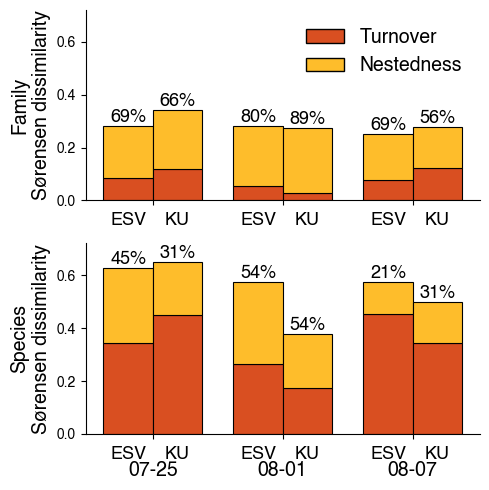

In [35]:
dates = ["07-25", "08-01", "08-07"]
dd = {("ESV","Family"):   {"turn":[0.086,0.056,0.078], "nest":[0.194,0.226,0.174]},("ESV","Species"):  {"turn":[0.345,0.264,0.452], "nest":[0.282,0.311,0.123]},("KU","Family"): {"turn":[0.118,0.030,0.121], "nest":[0.225,0.243,0.157]},("KU","Species"):{"turn":[0.451,0.174,0.345], "nest":[0.200,0.204,0.152]},}

x = np.arange(len(dates)); w = 0.38
fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=True)

for r, res in enumerate(["Family", "Species"]):
    ax = axes[r]
    for ci, clf in enumerate(["ESV", "KU"]):
        turn = np.array(dd[(clf,res)]["turn"]); nest = np.array(dd[(clf,res)]["nest"])
        off = (ci - 0.5) * w
        ax.bar(x+off, turn, w, color= "#d94f21", edgecolor="black", linewidth=0.8)
        ax.bar(x+off, nest, w, bottom=turn, color="#febd2b", edgecolor="black", linewidth=0.8)
        for k in range(len(dates)):
            frac = nest[k]/(turn[k]+nest[k])
            ax.text(k+off, turn[k]+nest[k]+0.015, f"{frac:.0%}", ha="center", fontsize=13, color="black")
            ax.text(k+off, -0.045, clf[:3].upper(), ha="center", va="top", fontsize=13, color="black")
    ax.set_xticks(x); ax.set_xticklabels(dates, fontsize=14)
    ax.tick_params(axis="x", pad=16)
    ax.set_ylabel(f"{res}\nSørensen dissimilarity", fontsize=14)
    ax.set_ylim(0, 0.72)
    ax.spines[["top","right"]].set_visible(False)

hh = [Patch(facecolor= "#d94f21", edgecolor="black", label="Turnover"), Patch(facecolor="#febd2b", edgecolor="black", label="Nestedness")]
axes[0].legend(handles=hh, fontsize=14, frameon=False, loc="upper right")
plt.tight_layout()

In [16]:
across_canal_bc.to_csv("ESV_across_canal_bc.csv")

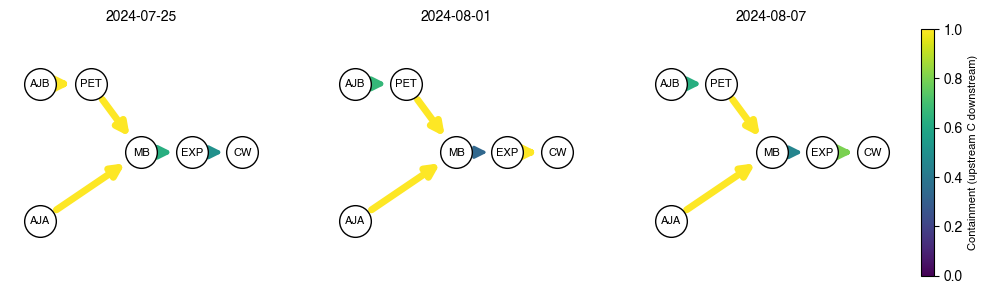

In [26]:
def matrices(df, value="read_count", level="species"):
    cdf = df.groupby(["dates","canal",level], as_index=False)[value].sum()
    out = {}
    for date in sorted(cdf["dates"].unique()):
        comm = (cdf[cdf.dates==date]
                .pivot(index="canal", columns=level, values=value).fillna(0))
        out[date] = comm.loc[[c for c in co if c in comm.index]]
    return out

directed = [(u,d) for u,ds in upstream.items() for d in ds]

# def containment(comm):
#     fam = {c:set(comm.columns[comm.loc[c].values>0]) for c in comm.index}
#     rows = []
#     for u,d in directed:
#         if u in fam and d in fam and fam[u]:
#             rows.append({"up":u, "down":d, "contain": len(fam[u]&fam[d])/len(fam[u])})
#     return pd.DataFrame(rows)

comms = matrices(df0, level="family")         
cont_by_date = {d: containment(comms[d]) for d in comms}
dates = sorted(comms)                         
pos = {"AJB": (0, 1.0), "PET": (1, 1.0), "AJA": (0, -1.0), "MB": (2, 0), "EXP": (3, 0), "CW": (4, 0)}
adj = [("AJB","PET"), ("PET","MB"), ("AJA","MB"), ("MB","EXP"), ("EXP","CW")]

cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(0.0, 1.0)        

fig, axes = plt.subplots(1, len(dates), figsize=(4*len(dates), 3.2), squeeze=False)
axes = axes[0]
for ax, date in zip(axes, dates):
    cont = cont_by_date[date].set_index(["up","down"])["contain"].to_dict()
    for a, b in adj:
        v = cont.get((a, b), np.nan)
        if np.isnan(v):
            col, lw = "#cccccc", 1.5
        else:
            col, lw = cmap(norm(v)), 1 + 4*v           
        ax.add_patch(FancyArrowPatch(pos[a], pos[b], arrowstyle="-|>", mutation_scale=18, lw=lw, color=col, shrinkA=14, shrinkB=14, zorder=1))
        
    for n, (px, py) in pos.items():
        ax.scatter(px, py, s=520, color="white", edgecolor="black", zorder=2)
        ax.text(px, py, n, ha="center", va="center", fontsize=8, zorder=3)
    
    ax.set_xlim(-0.6, 4.6); ax.set_ylim(-1.8, 1.8); ax.axis("off")
    ax.set_title(date, fontsize=10)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cb.set_label("Containment (upstream C downstream)", fontsize=8)


In [16]:
df0 = MT.copy()
df0["read_count"] = pd.to_numeric(df0["read_count"], errors="coerce").fillna(0)
df0["family"] = df0["family"].astype(str).str.replace("f__", "", regex=False)

def diversity(df, level):
    agg = df.groupby(["dates", "canal", level], as_index=False)["read_count"].sum()
    out = []
    for (date, canal), g in agg.groupby(["dates", "canal"]):
        counts = g["read_count"].values
        counts = counts[counts > 0]                    
        if counts.size == 0:
            richness = 0; H = np.nan; J = np.nan
        
        else:
            p = counts / counts.sum()
            richness = counts.size                     
            H = -(p * np.log(p)).sum()                  
            J = H / np.log(richness) if richness > 1 else np.nan   
        
        out.append({"date": date, "canal": canal, "richness": richness, "shannon": H, "evenness": J})
    return pd.DataFrame(out)

divdf = diversity(df0, "family")
divdf = divdf.sort_values(["canal", "date"]).reset_index(drop=True)
divdf

,date,canal,richness,shannon,evenness
0,2024-07-25,AJA,6,1.316575,0.734794
1,2024-08-01,AJA,7,1.110184,0.570522
2,2024-08-07,AJA,5,1.082504,0.672598
3,2024-07-25,AJB,4,0.896151,0.646436
4,2024-08-01,AJB,6,1.180048,0.658597
5,2024-08-07,AJB,8,1.546644,0.743779
6,2024-07-25,CW,3,0.788564,0.717782
7,2024-08-01,CW,4,1.121038,0.808658
8,2024-08-07,CW,6,0.908091,0.506815
9,2024-07-25,EXP,6,1.190126,0.664222


In [ ]:
df0 = MT.copy()  
df0["read_count"] = pd.to_numeric(df0["read_count"], errors="coerce").fillna(0)

agg = df0.groupby(["dates","canal","species"], as_index=False)["read_count"].sum()
rows = []
for (date, canal), g in agg.groupby(["dates","canal"]):
    c = g["read_count"].values; c = c[c > 0]
    depth = c.sum()
    if c.size == 0:
        H = np.nan; rich = 0
    else:
        p = c/c.sum(); H = -(p*np.log(p)).sum(); rich = c.size
    rows.append({"date":date, "canal":canal, "depth":depth, "richness":rich, "shannon":H})
div = pd.DataFrame(rows)

kw_canal = kruskal(*[g.shannon.dropna().values for _,g in div.groupby("canal")])
kw_date  = kruskal(*[g.shannon.dropna().values for _,g in div.groupby("date")])

In [ ]:
def pairwise_wilcox(dfv, group, val="shannon"):
    groups = sorted(dfv[group].unique()); out = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            a = dfv[dfv[group]==groups[i]][val].dropna()
            b = dfv[dfv[group]==groups[j]][val].dropna()
            if len(a) and len(b):
                p = ranksums(a, b).pvalue
                out.append({"g1":groups[i], "g2":groups[j], "p":p})
    r = pd.DataFrame(out)
    
    r["p_bh"] = false_discovery_control(r["p"])   
    return r

pw_canal = pairwise_wilcox(div, "canal")

In [ ]:
kw_rich = kruskal(*[g.richness.dropna().values for _,g in div.groupby("canal")])

r_p, p_p = pearsonr(div.depth, div.richness)
r_s, p_s = spearmanr(div.depth, div.richness)
r_log, p_log = pearsonr(np.log10(div.depth.replace(0,np.nan).dropna()), div.loc[div.depth>0,"richness"])

In [ ]:
kw_depth = kruskal(*[g.depth.dropna().values for _, g in div.groupby("canal")])

In [ ]:
div = div.copy()
m, b = np.polyfit(div.depth, div.richness, 1)
div["rich_resid"] = div.richness - (m * div.depth + b)  
kw_resid = kruskal(*[g.rich_resid.dropna().values for _, g in div.groupby("canal")])

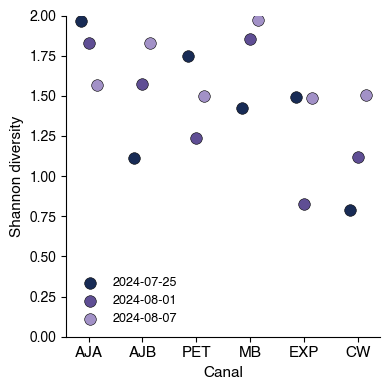

In [21]:
canals = [c for c in co if c in div.canal.values]
dd  = sorted(div["date"].unique())
date_colors = dict(zip(dd, ["#182b55", "#5f4e94", "#a291c7", "#82cbec"]))
jit = np.linspace(-0.15, 0.15, len(dd))   

fig, ax = plt.subplots(figsize=(4, 4))
for k, date in enumerate(dd):
    d = div[div.date == date]
    xs = [canals.index(c) + jit[k] for c in d["canal"] if c in canals]
    ys = [d[d.canal == c]["shannon"].values[0] for c in d["canal"] if c in canals]
    ax.scatter(xs, ys, color=date_colors[date], s=70, edgecolor="black", linewidth=0.4, label=date, zorder=3)

ax.set_xticks(range(len(canals))); ax.set_xticklabels(canals, fontsize=11)
ax.set_xlabel("Canal", fontsize=11)
ax.set_ylabel("Shannon diversity", fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.legend(title="", fontsize=9, title_fontsize=10, frameon=False, loc="lower left")

ax.set_ylim(0,2)
plt.tight_layout()